# 07 - Evaluation

All strategies are compared on identical simulated seasons using **common random numbers**:
every policy faces the same pre-drawn demand percentiles and the same market-regime path.
Differences therefore reflect the policies rather than luck, the samples are genuinely
paired, and the standard errors shrink by roughly an order of magnitude.

Seven strategies, spanning the comparisons the brief asks for:

| strategy | type |
|---|---|
| random | no pricing logic at all |
| naive 1.00x | fixed pricing, no dynamic adjustment |
| best fixed | fixed pricing, best possible constant rate |
| pace heuristic | rule-based industry practice |
| MILP schedule | integer programming, open loop |
| Double Q-learning | model-free RL |
| DP optimal | model-based RL / exact optimum |

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from plotting import use_style, save_fig, colour
use_style()

import joblib
from scipy import stats
from config import MULTIPLIERS, HORIZON, RESULTS, REGIME_NAMES
from environment import HotelPricingEnv
from metrics import compare, paired_tests, draw_common_randoms, occupancy_paths, price_paths
from mdp import dp_policy
import policies as P

env = HotelPricingEnv("City Hotel", "May", seed=0)
Q = np.load(RESULTS / "q_table.npy")
pi_star = np.load(RESULTS / "vi_policy.npy")
schedule = np.load(RESULTS / "lp_schedule.npy")
V_STAR = joblib.load(RESULTS / "vi_solution.joblib")["V_star"]

tune = draw_common_randoms(env, 500, seed=31337)
from metrics import evaluate
fixed_means = [evaluate(env, P.fixed_policy(a), tune)["reward"].mean()
               for a in range(env.n_actions)]
best_a = int(np.argmax(fixed_means))
print(f"best constant rate (tuned on a held-out seed stream): {MULTIPLIERS[best_a]:.2f}x")

best constant rate (tuned on a held-out seed stream): 1.15x


In [2]:
pace_target = P.naive_pace_curve(HotelPricingEnv("City Hotel", "May", seed=7), n=1500)

strategies = {
    "random": P.random_policy(0),
    "naive 1.00x": P.naive_policy(),
    f"best fixed {MULTIPLIERS[best_a]:.2f}x": P.fixed_policy(best_a),
    "pace heuristic": P.pace_heuristic(pace_target),
    "MILP schedule": P.lp_policy(schedule),
    "Double Q-learning": P.greedy_q_policy(Q),
    "DP optimal": dp_policy(pi_star),
}
summary, raw = compare(env, strategies, n_episodes=4000, seed=777)
summary["vs_naive_%"] = 100 * (summary["net_revenue"] / summary.loc["naive 1.00x", "net_revenue"] - 1)
summary["% of V*"] = 100 * summary["net_revenue"] / V_STAR
summary.round(2)

,net_revenue,ci95,gross_revenue,revpar,adr,occupancy,sell_out_rate,turned_away,mean_multiplier,vs_naive_%,% of V*
strategy,,,,,,,,,,,
random,386329.49,1495.79,389459.27,68.54,69.96,0.98,0.88,328.16,1.07,-13.78,73.05
naive 1.00x,448073.71,452.44,452270.71,79.60,79.60,1.00,1.00,349.75,1.00,0.00,84.73
best fixed 1.15x,457270.23,1493.02,457272.18,80.48,98.31,0.82,0.01,0.14,1.15,2.05,86.47
pace heuristic,443460.53,620.80,448536.58,78.94,78.94,1.00,1.00,425.05,1.06,-1.03,83.86
MILP schedule,510234.43,1236.61,511313.38,89.99,95.73,0.94,0.49,105.78,1.34,13.87,96.48
Double Q-learning,524652.37,664.51,525531.08,92.49,93.41,0.99,0.66,83.13,1.19,17.09,99.21
DP optimal,528570.02,673.81,529357.75,93.16,94.25,0.99,0.62,75.43,1.20,17.96,99.95


## 1. Reading the table

Revenue is not the only thing that separates these strategies, and the secondary columns
show why. `naive 1.00x` sells out almost every season and turns away hundreds of guests -
it is leaving rate on the table. `best fixed 1.15x` protects rate but ends the season at
82% occupancy. The two learned policies get both: high realised ADR *and* high occupancy,
because they price low enough to fill early and high enough to capture the late surge.

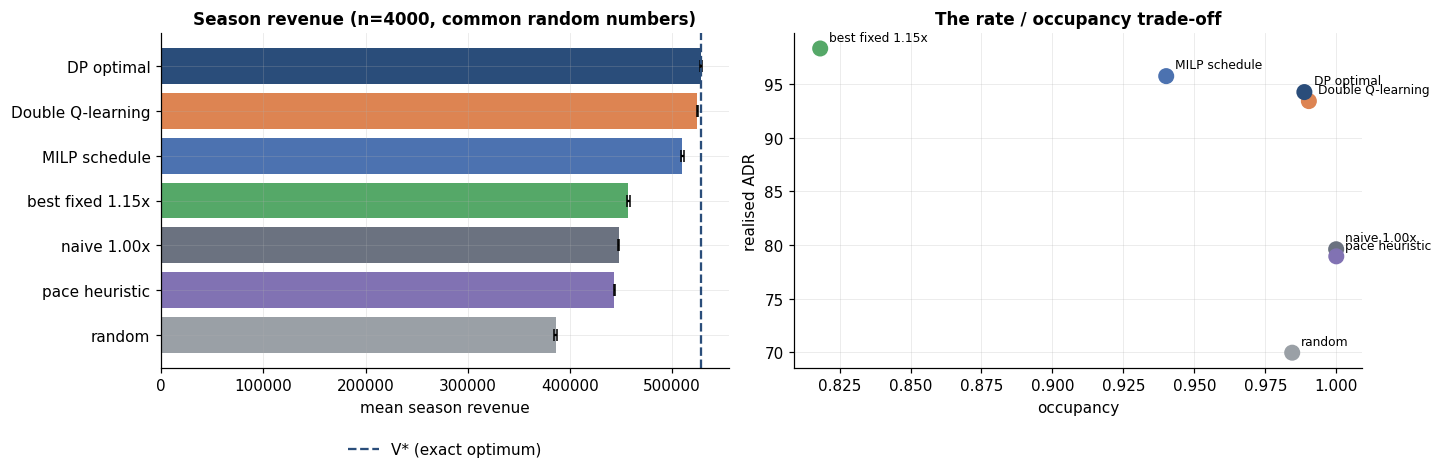

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
order = summary.sort_values("net_revenue").index
colours = [colour(s) for s in order]

axes[0].barh(range(len(order)), summary.loc[order, "net_revenue"],
             xerr=summary.loc[order, "ci95"], color=colours, capsize=4)
axes[0].axvline(V_STAR, color="#2a4d7a", ls="--", lw=1.5, label="V* (exact optimum)")
axes[0].set(yticks=range(len(order)), yticklabels=order, xlabel="mean season revenue",
            title="Season revenue (n=4000, common random numbers)")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18))

axes[1].scatter(summary["occupancy"], summary["adr"], s=90, c=[colour(s) for s in summary.index],
                zorder=3)
for name, row in summary.iterrows():
    axes[1].annotate(name, (row["occupancy"], row["adr"]), textcoords="offset points",
                     xytext=(6, 5), fontsize=8)
axes[1].set(xlabel="occupancy", ylabel="realised ADR",
            title="The rate / occupancy trade-off")
save_fig("07_strategy_comparison")
plt.show()

## 2. Significance

Paired t-tests against list pricing, with **Holm** correction for the family of
comparisons and **Cohen's d** alongside each t statistic. With 4,000 paired episodes
almost anything is "significant", so the effect size is what carries the meaning: `d`
above 0.8 is a large effect, and the two learned policies clear that comfortably while the
pace heuristic does not.

In [4]:
tests = paired_tests(raw, "naive 1.00x")
tests.round(4)

,mean_diff,lift_pct,t,p_raw,cohens_d,p_holm,significant_05
strategy,,,,,,,
random,-61744.2120,-13.7799,-80.0107,0.0,-1.2651,0.0,True
MILP schedule,62160.7236,13.8729,81.4998,0.0,1.2886,0.0,True
DP optimal,80496.3111,17.9650,159.0171,0.0,2.5143,0.0,True
Double Q-learning,76578.6640,17.0906,152.3979,0.0,2.4096,0.0,True
best fixed 1.15x,9196.5271,2.0525,9.8141,0.0,0.1552,0.0,True
pace heuristic,-4613.1756,-1.0296,-9.5258,0.0,-0.1506,0.0,True


In [5]:
best_fixed_name = f"best fixed {MULTIPLIERS[best_a]:.2f}x"
head_to_head = paired_tests({k: raw[k] for k in
                             ["Double Q-learning", best_fixed_name, "MILP schedule", "DP optimal"]},
                            best_fixed_name)
print("Is the learned policy better than the best constant rate?\n")
print(head_to_head.round(4).to_string())

Is the learned policy better than the best constant rate?

                    mean_diff  lift_pct         t  p_raw  cohens_d  p_holm  significant_05
strategy                                                                                  
Double Q-learning  67382.1369   14.7357  139.5329    0.0    2.2062     0.0            True
MILP schedule      52964.1965   11.5827  130.9174    0.0    2.0700     0.0            True
DP optimal         71299.7839   15.5925  151.9994    0.0    2.4033     0.0            True


## 3. How the strategies behave over the season

The averages hide the mechanism. The pace plot shows *when* each strategy fills the hotel;
the price plot shows the rate path that produces it. The learned policies discount early to
build a base, then raise rates steeply as inventory tightens - the opposite of the fixed
strategies, which by construction cannot respond at all.

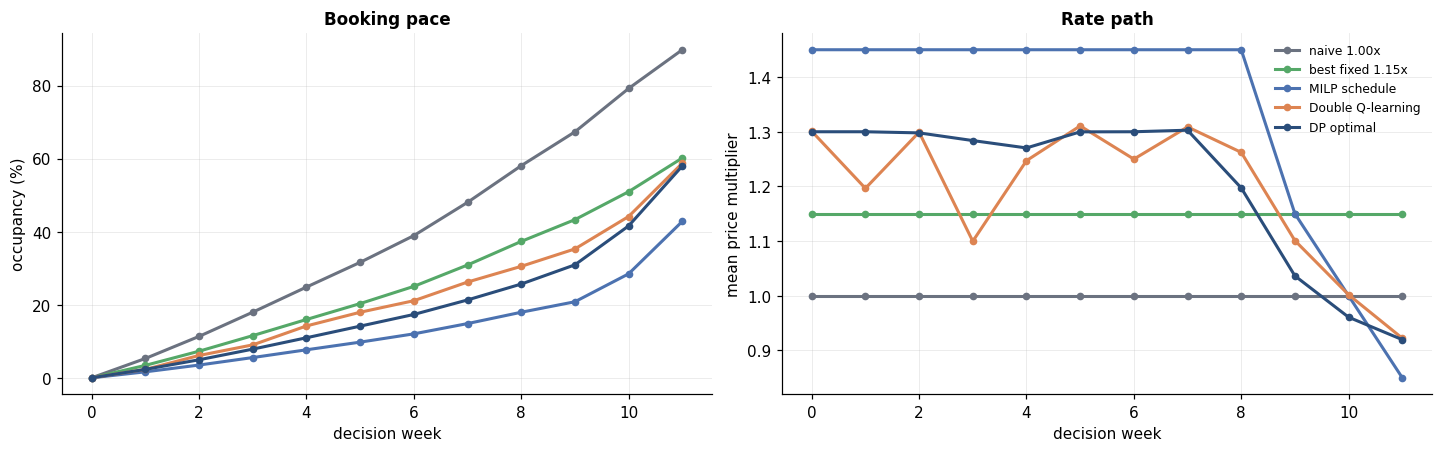

In [6]:
paths_commons = draw_common_randoms(env, 800, seed=2024)
shown = ["naive 1.00x", best_fixed_name, "MILP schedule", "Double Q-learning", "DP optimal"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name in shown:
    occ = np.nanmean(occupancy_paths(env, strategies[name], paths_commons), axis=0)
    prc = np.nanmean(price_paths(env, strategies[name], paths_commons), axis=0)
    axes[0].plot(range(HORIZON), 100 * occ, "o-", lw=2, color=colour(name), label=name, ms=4)
    axes[1].plot(range(HORIZON), prc, "o-", lw=2, color=colour(name), label=name, ms=4)
axes[0].set(xlabel="decision week", ylabel="occupancy (%)", title="Booking pace")
axes[1].set(xlabel="decision week", ylabel="mean price multiplier", title="Rate path")
axes[1].legend(fontsize=8)
save_fig("07_season_dynamics")
plt.show()

## 4. Robustness to the elasticity assumption

Elasticity is the least certain input: notebook 02 showed the naive regression and the
willingness-to-pay estimator bias in opposite directions. Re-solving and re-evaluating
across a wide elasticity range tests whether the conclusion survives.

The DP policy is re-solved at each elasticity (it is model-based, so it adapts). The
Q-learning policy is **not** retrained - it is the one learned at the estimated elasticity,
so this also measures how badly a misspecified model hurts a deployed agent.

In [7]:
from mdp import value_iteration, optimal_value

rows = []
for eps in [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]:
    e = HotelPricingEnv("City Hotel", "May", elasticity=eps, seed=0)
    v, pol, _ = value_iteration(e)
    strat = {"naive 1.00x": P.naive_policy(),
             "best fixed": P.fixed_policy(best_a),
             "Double Q-learning": P.greedy_q_policy(Q),
             "DP optimal": dp_policy(pol)}
    s, _ = compare(e, strat, n_episodes=800, seed=777)
    base = s.loc["naive 1.00x", "net_revenue"]
    rows.append({"elasticity": eps,
                 "best fixed": 100 * (s.loc["best fixed", "net_revenue"] / base - 1),
                 "Double Q-learning": 100 * (s.loc["Double Q-learning", "net_revenue"] / base - 1),
                 "DP optimal": 100 * (s.loc["DP optimal", "net_revenue"] / base - 1)})
robustness = pd.DataFrame(rows).set_index("elasticity")
robustness.round(1)

,best fixed,Double Q-learning,DP optimal
elasticity,,,
1.5,18.6,22.7,26.5
2.0,15.8,20.1,21.7
2.5,10.5,18.2,19.3
3.0,3.7,17.2,17.9
3.5,-3.3,15.5,16.9
4.0,-9.8,12.7,16.4


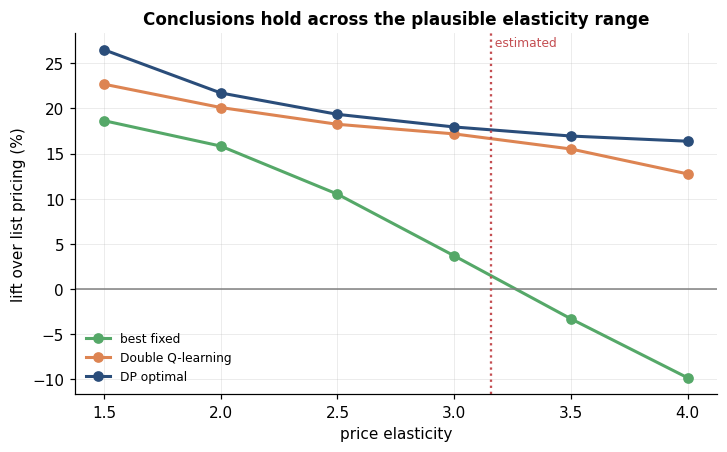

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for name in robustness.columns:
    ax.plot(robustness.index, robustness[name], "o-", lw=2, color=colour(name), label=name)
ax.axhline(0, color="grey", lw=1)
ax.axvline(env.elasticity, color="#c44e52", ls=":", lw=1.5)
ax.text(env.elasticity, ax.get_ylim()[1] * 0.95, " estimated", color="#c44e52", fontsize=8)
ax.set(xlabel="price elasticity", ylabel="lift over list pricing (%)",
       title="Conclusions hold across the plausible elasticity range")
ax.legend(fontsize=8)
save_fig("07_elasticity_robustness")
plt.show()

## 5. Generalisation across all 24 (hotel, month) cells

Everything so far concerns City Hotel in May. Re-solving for every hotel and month tests
whether the approach generalises or was tuned to one cell. The Q-table trained on City/May
is applied **unchanged** to all 24 cells - a genuine zero-shot transfer test.

In [9]:
from config import MONTH_ORDER

records = []
for hotel in ["City Hotel", "Resort Hotel"]:
    for month in MONTH_ORDER:
        e = HotelPricingEnv(hotel, month, seed=0)
        v, pol, _ = value_iteration(e)
        s, _ = compare(e, {"naive 1.00x": P.naive_policy(),
                           "best fixed": P.fixed_policy(best_a),
                           "Double Q-learning": P.greedy_q_policy(Q),
                           "DP optimal": dp_policy(pol)}, n_episodes=300, seed=777)
        base = s.loc["naive 1.00x", "net_revenue"]
        records.append({"hotel": hotel, "month": month,
                        "best fixed": 100 * (s.loc["best fixed", "net_revenue"] / base - 1),
                        "Double Q-learning": 100 * (s.loc["Double Q-learning", "net_revenue"] / base - 1),
                        "DP optimal": 100 * (s.loc["DP optimal", "net_revenue"] / base - 1)})
generalisation = pd.DataFrame(records)
generalisation.groupby("hotel")[["best fixed", "Double Q-learning", "DP optimal"]].mean().round(1)

,best fixed,Double Q-learning,DP optimal
hotel,,,
City Hotel,10.3,23.6,27.0
Resort Hotel,31.5,43.1,56.8


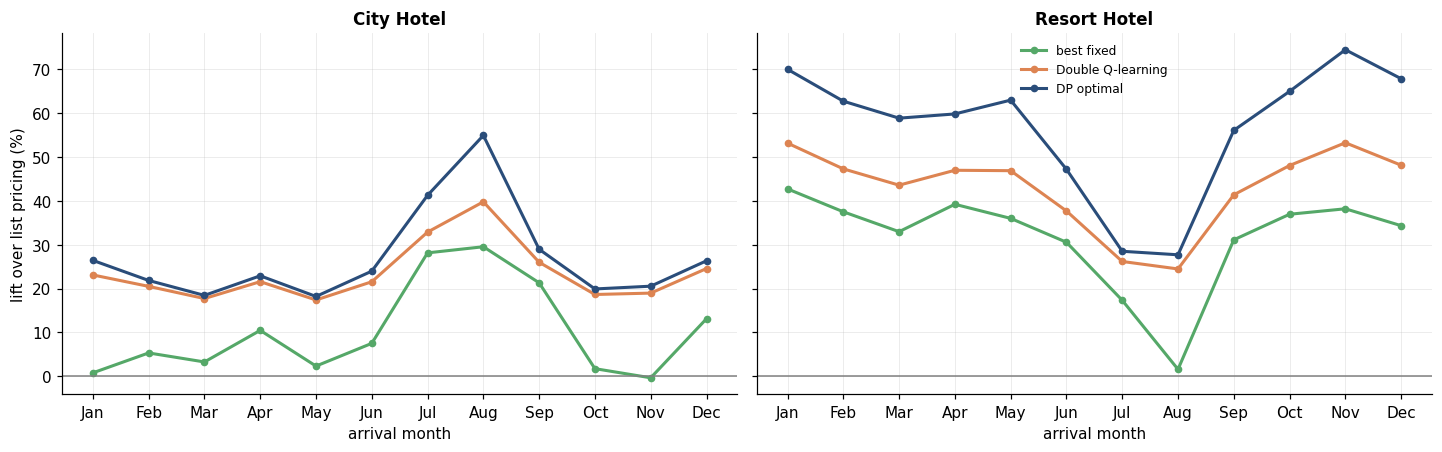

zero-shot Q-learning lift across 24 cells: median 29.5%, range 17.4% to 53.3%
cells where it beats list pricing: 24/24


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, hotel in zip(axes, ["City Hotel", "Resort Hotel"]):
    sub = generalisation[generalisation["hotel"] == hotel].set_index("month")
    sub = sub.reindex(MONTH_ORDER)
    for name in ["best fixed", "Double Q-learning", "DP optimal"]:
        ax.plot(range(12), sub[name], "o-", lw=2, color=colour(name), label=name, ms=4)
    ax.axhline(0, color="grey", lw=1)
    ax.set(title=hotel, xticks=range(12),
           xticklabels=[m[:3] for m in MONTH_ORDER], xlabel="arrival month")
axes[0].set_ylabel("lift over list pricing (%)")
axes[1].legend(fontsize=8)
save_fig("07_generalisation")
plt.show()

lifts = generalisation["Double Q-learning"]
print(f"zero-shot Q-learning lift across 24 cells: median {lifts.median():.1f}%, "
      f"range {lifts.min():.1f}% to {lifts.max():.1f}%")
print(f"cells where it beats list pricing: {(lifts > 0).sum()}/24")

## 6. Summary of findings

**The optimal policy is worth having.** Acting on inventory and market conditions earns
materially more than the best possible constant rate - and the constant rate is itself a
generous baseline, since it is chosen with hindsight over the whole action grid.

**Both algorithms work, and they need different things.** Value Iteration is exact but
requires the transition kernel written out; Double Q-learning needs nothing but sampled
seasons and still recovers ~99% of the optimum. Notebook 05 splits that 0.7% shortfall
exactly: roughly 0.3 points are the price of seeing occupancy only as a decile, and 0.4
points are residual learning error. Neither dominates, so both a finer state and more
training would buy a little more - but there is very little left to buy.

**Open-loop optimisation is not enough.** The MILP's objective *exceeds* the true optimum
because it plans against mean demand, yet the schedule it produces earns less than either
adaptive policy when replayed under real uncertainty. Committing to a rate plan in advance
is the expensive part, not the optimisation.

**The rule-based heuristic does not help.** Pace management lands about 1% *below* list
pricing. It reacts to occupancy but never values the inventory it gives up, so it discounts
when it is behind pace even in weeks when holding the rate would have been worth more. Being
state-dependent is not sufficient; the state has to be used to weigh a trade-off.

**Limitations.** Elasticity is the weakest link: it is not identified from observational
data, and the two estimators bracket rather than pin it, though section 4 shows the ranking
is stable across the plausible range. The simulator also assumes demand is independent
across weeks, so it cannot represent guests who delay booking in anticipation of a
discount - strategic customer behaviour would reduce the gains reported here.

In [11]:
final = summary[["net_revenue", "gross_revenue", "ci95", "revpar", "adr", "occupancy", "sell_out_rate",
                 "vs_naive_%", "% of V*"]].sort_values("net_revenue", ascending=False)
final.round(2).to_csv(RESULTS / "final_comparison.csv")
joblib.dump({"summary": summary, "tests": tests, "robustness": robustness,
             "generalisation": generalisation}, RESULTS / "evaluation.joblib")
final.round(2)

,net_revenue,gross_revenue,ci95,revpar,adr,occupancy,sell_out_rate,vs_naive_%,% of V*
strategy,,,,,,,,,
DP optimal,528570.02,529357.75,673.81,93.16,94.25,0.99,0.62,17.96,99.95
Double Q-learning,524652.37,525531.08,664.51,92.49,93.41,0.99,0.66,17.09,99.21
MILP schedule,510234.43,511313.38,1236.61,89.99,95.73,0.94,0.49,13.87,96.48
best fixed 1.15x,457270.23,457272.18,1493.02,80.48,98.31,0.82,0.01,2.05,86.47
naive 1.00x,448073.71,452270.71,452.44,79.60,79.60,1.00,1.00,0.00,84.73
pace heuristic,443460.53,448536.58,620.80,78.94,78.94,1.00,1.00,-1.03,83.86
random,386329.49,389459.27,1495.79,68.54,69.96,0.98,0.88,-13.78,73.05
